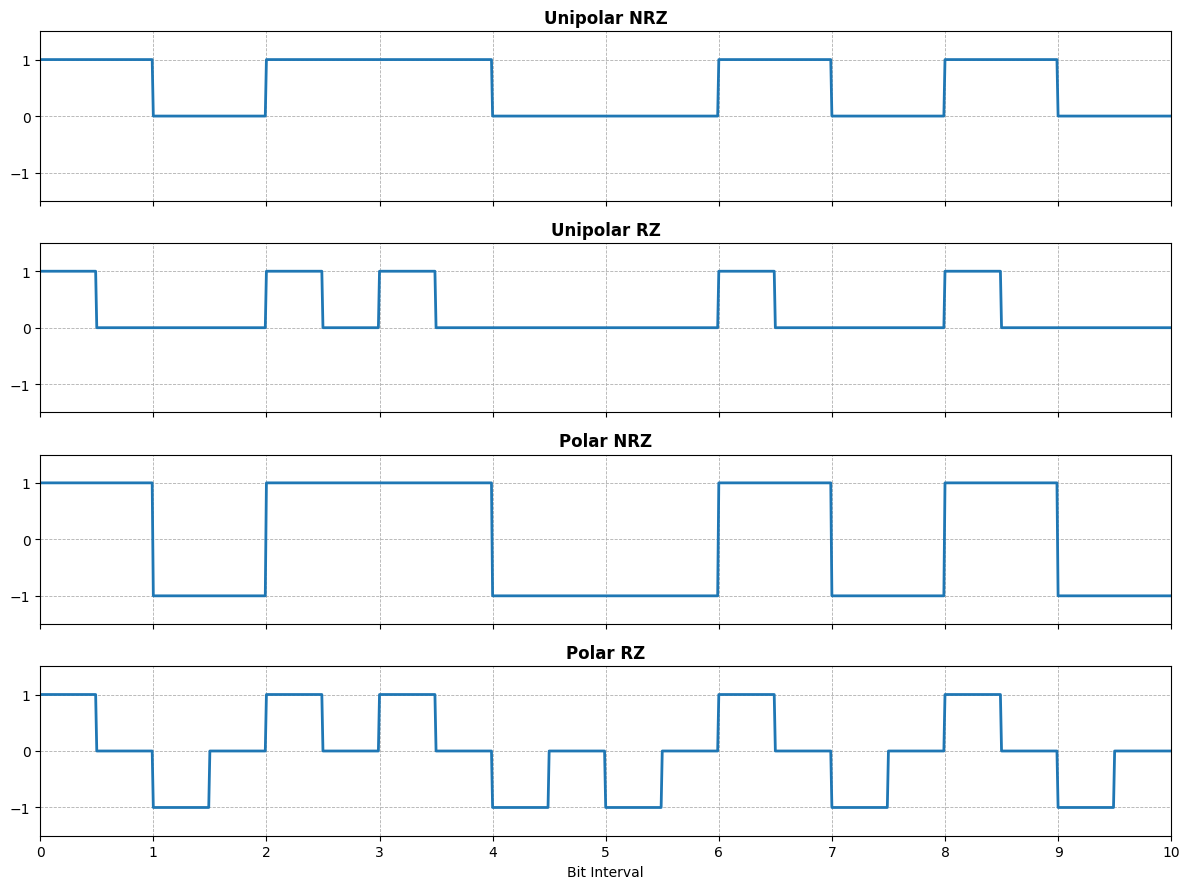

In [3]:
import numpy as np
import matplotlib.pyplot as plt

bits = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0])
A = 1
samples_per_bit = 100


def repeat_bits(levels, samples_per_bit):
    return np.repeat(levels, samples_per_bit)


def rz_waveform(levels, samples_per_bit):
    half = samples_per_bit // 2
    waveform = []
    for level in levels:
        waveform.extend([level] * half)
        waveform.extend([0] * (samples_per_bit - half))
    return np.array(waveform)


unipolar_nrz_levels = np.where(bits == 1, A, 0)
unipolar_nrz = repeat_bits(unipolar_nrz_levels, samples_per_bit)

unipolar_rz = rz_waveform(unipolar_nrz_levels, samples_per_bit)

polar_nrz_levels = np.where(bits == 1, A, -A)
polar_nrz = repeat_bits(polar_nrz_levels, samples_per_bit)

polar_rz = rz_waveform(polar_nrz_levels, samples_per_bit)

t = np.arange(len(bits) * samples_per_bit) / samples_per_bit

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

titles = ["Unipolar NRZ", "Unipolar RZ", "Polar NRZ", "Polar RZ"]
signals = [unipolar_nrz, unipolar_rz, polar_nrz, polar_rz]

bit_edges = np.arange(0, len(bits) + 1, 1)

for ax, sig, title in zip(axes, signals, titles):
    ax.plot(t, sig, linewidth=2)
    ax.set_title(title, fontsize=12, weight='bold')
    ax.set_yticks([-A, 0, A])
    ax.set_xticks(bit_edges)
    ax.grid(True, which='major', linestyle='--', linewidth=0.6)
    ax.set_xlim(0, len(bits))
    ax.set_ylim(-1.5 * A, 1.5 * A)

axes[-1].set_xlabel("Bit Interval")

plt.tight_layout()
plt.show()

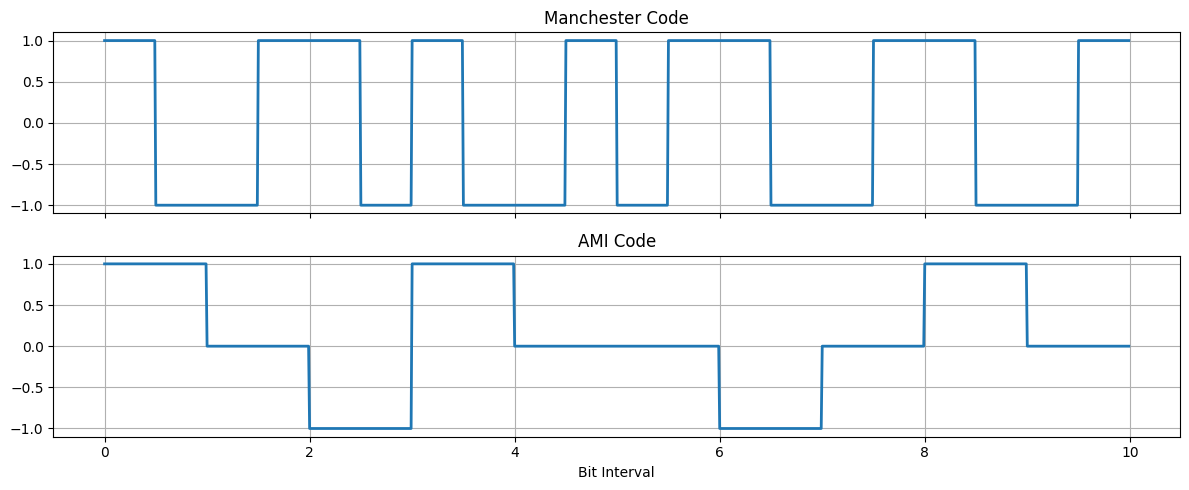

In [4]:
import numpy as np
import matplotlib.pyplot as plt

bits = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0])
A = 1
samples_per_bit = 100
half = samples_per_bit // 2


def manchester_encode(bits, A, samples_per_bit):
    half = samples_per_bit // 2
    waveform = []
    for bit in bits:
        if bit == 1:
            waveform.extend([A] * half)
            waveform.extend([-A] * (samples_per_bit - half))
        else:
            waveform.extend([-A] * half)
            waveform.extend([A] * (samples_per_bit - half))
    return np.array(waveform)


def ami_encode(bits, A, samples_per_bit):
    waveform = []
    last_mark = -A
    for bit in bits:
        if bit == 1:
            last_mark = -last_mark
            waveform.extend([last_mark] * samples_per_bit)
        else:
            waveform.extend([0] * samples_per_bit)
    return np.array(waveform)


manchester = manchester_encode(bits, A, samples_per_bit)
ami = ami_encode(bits, A, samples_per_bit)
t = np.arange(len(bits) * samples_per_bit) / samples_per_bit

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t, manchester, linewidth=2)
axes[0].set_title("Manchester Code")
axes[0].grid(True)

axes[1].plot(t, ami, linewidth=2)
axes[1].set_title("AMI Code")
axes[1].set_xlabel("Bit Interval")
axes[1].grid(True)

plt.tight_layout()
plt.show()